# Figure for the NISAR proposal

The aim is to show that (a) we can run the algorithm on data from the Arctic and the Antarctic and (b) it provides information on sea ice properties as well as on sea ice motion. 

In [1]:
import ultraplot as uplt
import pandas as pd
import numpy as np
import skimage
import cartopy.crs as ccrs
import pyproj

uplt.rc['geo.round'] = False
uplt.rc['reso'] = 'med'

In [102]:
# Greenland images and tracking results
dataloc = '../data/greenland_sea/'
tracked = pd.read_csv(dataloc + 'greenland-sea-tracking_2023-05-16_2023-05-20.csv', parse_dates=["passtime"])
for floe_id, data in tracked.groupby("trajectory_uuid"):
    dt = (data.shift(-1)['passtime'] - data['passtime']).dt.total_seconds()
    tracked.loc[data.index, 'dt'] = dt
    tracked.loc[data.index, 'dx'] = 250 * (data.shift(-1)['col_centroid'] - data['col_centroid'])
    tracked.loc[data.index, 'dy'] = -250 * (data.shift(-1)['row_centroid'] - data['row_centroid'])
colors = [c['color'] for c in uplt.Cycle('managua', 20)]
for floe_id, group in tracked.groupby("ID"):
    tracked.loc[group.index, "color"] = np.random.choice(colors, 1)[0]
    
grouped = {date: group for date, group in tracked.groupby("passtime")}
images = {}
segments = {}
clouds = {}
ice = {}
for date in grouped:
    satellite = grouped[date].satellite.values[0]
    land = skimage.io.imread(dataloc + "greenland-sea-300km/250m.2023.landmask.tiff").squeeze()
    images[date] = skimage.io.imread(dataloc + "greenland-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/truecolor.tiff")
    clouds[date] = skimage.io.imread(dataloc + "greenland-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/cloud_mask.png")
    ice[date] = skimage.io.imread(dataloc + "greenland-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/ice_mask.png")
    s = skimage.io.imread(dataloc + "greenland-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/segments.png")
    segments[date] = skimage.measure.label(s) 
    CC = np.floor(grouped[date].col_centroid).astype(int)
    RC = np.floor(grouped[date].row_centroid).astype(int)
    grouped[date]['label'] = segments[date][RC, CC] # Update label with new value
satellites = tracked.groupby('passtime').apply(lambda x: x.satellite.values[0], include_groups=False)
dates = [x for x in grouped.keys()]

# Get vectors for Greenland case
start_idx = 0
plot_date = dates[start_idx]

df = tracked.groupby("ID").filter(lambda x: dates[start_idx] in x.passtime.values)
df = df.groupby("ID").filter(lambda x: dates[start_idx + 2] in x.passtime.values)
# df.loc[df.passtime.between(plot_date, plot_date + pd.to_timedelta(1.5, unit='days'))]
df_1day = df.loc[df.passtime.between(dates[start_idx], dates[start_idx + 2]) & (df.satellite=='aqua')].copy()
for floe_id, data in df_1day.groupby('ID'):
    dt = (data.shift(-1)['passtime'] - data['passtime']).dt.total_seconds()
    df_1day.loc[data.index, 'dt'] = dt
    df_1day.loc[data.index, 'dx'] = 250 * (data.shift(-1)['col_centroid'] - data['col_centroid'])
    df_1day.loc[data.index, 'dy'] = -250 * (data.shift(-1)['row_centroid'] - data['row_centroid'])
    df_1day.loc[data.index, 'U'] = np.sqrt(
        (df_1day.loc[data.index, 'dx']/df_1day.loc[data.index, 'dt'])**2 + (df_1day.loc[data.index, 'dy']/df_1day.loc[data.index, 'dt'])**2
    )
du = df_1day.dx / df_1day.dt
dv = df_1day.dy / df_1day.dt
zu = (du - du.mean())/du.std()
zv = (dv - dv.mean())/dv.std()

idx = (zu**2 + zv**2)**0.5 < 0.75
greenland_date = plot_date.strftime('%Y-%m-%d')
greenland_tc = images[plot_date]
greenland_clouds = clouds[plot_date]
greenland_ice = ice[plot_date]
greenland_segments = segments[plot_date]
greenland_date = plot_date.strftime('%Y-%m-%d')

greenland_x = df_1day.col_centroid[idx]
greenland_y = df_1day.row_centroid[idx]
greenland_u = (df_1day.dx/df_1day.dt)[idx]
greenland_v = (df_1day.dy/df_1day.dt)[idx]

In [103]:
# Examine greenland vectors
len(df_1day.col_centroid[idx]), len(greenland_x)

(83, 83)

In [105]:
df_1day['w_shift'] = df_1day.w.shift(1)

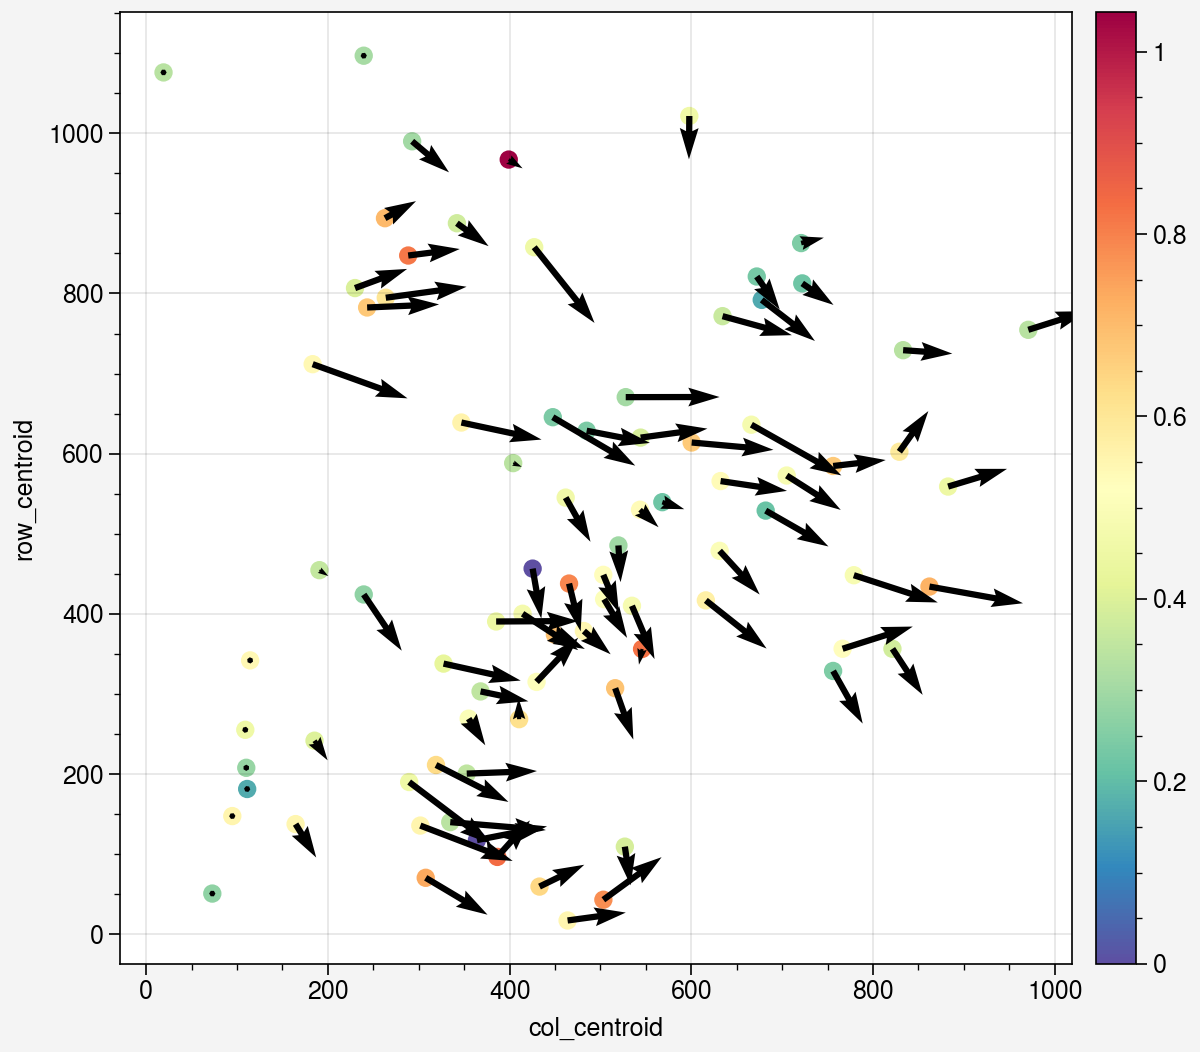

In [109]:
fig, ax = uplt.subplots(width=6)
ax.scatter(greenland_x, greenland_y, c=df_1day.w_shift[idx].fillna(0), cmap='spectral_r', colorbar='r')
ax.quiver(greenland_x, greenland_y, greenland_u, greenland_v)

In [85]:
# Antarctic images and tracking results
dataloc = '../data/weddell_sea/'
tracked = pd.read_csv(dataloc + 'weddell_sea_tracking_2025-12-09_2025-12-12.csv', parse_dates=["passtime"])
for floe_id, data in tracked.groupby("trajectory_uuid"):
    dt = (data.shift(-1)['passtime'] - data['passtime']).dt.total_seconds()
    tracked.loc[data.index, 'dt'] = dt
    tracked.loc[data.index, 'dx'] = 250 * (data.shift(-1)['col_centroid'] - data['col_centroid'])
    tracked.loc[data.index, 'dy'] = -250 * (data.shift(-1)['row_centroid'] - data['row_centroid'])
colors = [c['color'] for c in uplt.Cycle('managua', 20)]
for floe_id, group in tracked.groupby("ID"):
    tracked.loc[group.index, "color"] = np.random.choice(colors, 1)[0]
    
grouped = {date: group for date, group in tracked.groupby("passtime")}
images = {}
segments = {}
clouds = {}
ice = {}
for date in grouped:
    satellite = grouped[date].satellite.values[0]
    images[date] = skimage.io.imread(dataloc + "weddell-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/truecolor.tiff")
    clouds[date] = skimage.io.imread(dataloc + "weddell-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/cloud_mask.png")
    ice[date] = skimage.io.imread(dataloc + "weddell-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/ice_mask.png")
    s = skimage.io.imread(dataloc + "weddell-sea-300km.250m." + date.strftime("%Y-%m-%d") + "." + satellite + "/segments.png")
    segments[date] = skimage.measure.label(s) 
    CC = np.floor(grouped[date].col_centroid).astype(int)
    RC = np.floor(grouped[date].row_centroid).astype(int)
    grouped[date]['label'] = segments[date][RC, CC] # Update label with new value

satellites = tracked.groupby('passtime').apply(lambda x: x.satellite.values[0], include_groups=False)
dates = [x for x in grouped.keys()]

# Get vectors for Greenland case
start_idx = 3
plot_date = dates[start_idx]


# Get vectors for Antarctica case
df = tracked.groupby("ID").filter(lambda x: dates[start_idx] in x.passtime.values)
df = df.groupby("ID").filter(lambda x: dates[start_idx + 2] in x.passtime.values)
df.loc[df.passtime.between(plot_date, plot_date + pd.to_timedelta(1.1, unit='days'))]
df_1day = df.loc[df.passtime.between(dates[start_idx], dates[start_idx + 2]) & (df.satellite=='terra')].copy()
for floe_id, data in df_1day.groupby('ID'):
    dt = (data.shift(-1)['passtime'] - data['passtime']).dt.total_seconds()
    df_1day.loc[data.index, 'dt'] = dt
    df_1day.loc[data.index, 'dx'] = 250 * (data.shift(-1)['col_centroid'] - data['col_centroid'])
    df_1day.loc[data.index, 'dy'] = -250 * (data.shift(-1)['row_centroid'] - data['row_centroid'])
    df_1day.loc[data.index, 'U'] = np.sqrt(
        (df_1day.loc[data.index, 'dx']/df_1day.loc[data.index, 'dt'])**2 + (df_1day.loc[data.index, 'dy']/df_1day.loc[data.index, 'dt'])**2
    )
du = df_1day.dx / df_1day.dt
dv = df_1day.dy / df_1day.dt
zu = (du - du.mean())/du.std()
zv = (dv - dv.mean())/dv.std()

idx = (zu**2 + zv**2)**0.5 < 0.25    

antarctic_tc = images[plot_date]
antarctic_clouds = clouds[plot_date]
antarctic_ice = ice[plot_date]
antarctic_segments = segments[plot_date]
antarctic_date = plot_date.strftime('%Y-%m-%d')

antarctic_x = df_1day.col_centroid[idx]
antarctic_y = df_1day.row_centroid[idx]
antarctic_u = (df_1day.dx/df_1day.dt)[idx]
antarctic_v = (df_1day.dy/df_1day.dt)[idx]

In [114]:
fig = uplt.Figure(share=False)
nrows=2
ncols=3
ax = fig.subplot(nrows, ncols, 1, proj='npstere', proj_kw={'central_longitude': -45})

greenland_lat = 73.08
greenland_lon = -17.01
proj_LL = 'epsg:4326' # WGS 84 Ellipsoid
proj_XY = 'epsg:3413' # NSIDC Polar Stereographic
transform_to_xy = pyproj.Transformer.from_crs(proj_LL, proj_XY, always_xy=True)
x0, y0 = transform_to_xy.transform(greenland_lon, greenland_lat)
dx = 150e3

ax.set_extent([x0 - 700e3, x0 + 800e3, y0 - 800e3, y0 + 700e3], crs=ccrs.Projection(ccrs.CRS(proj_XY)))

ax.format(land=True, latmax=90, latlocator=np.arange(60, 90, 5), lonlocator=np.arange(-50, 55, 5), labels=True)
ax.plot([x0 - dx, x0 + dx, x0 + dx, x0 - dx, x0 - dx],
        [y0 - dx, y0 - dx, y0 + dx, y0 + dx, y0 - dx], color='r', transform=ccrs.Projection(ccrs.CRS('epsg:3413')))
ax.text(-10, 76, "Greenland Sea", transform=ccrs.PlateCarree())
ax.format(title='Location')

#### Truecolor Images
ax = fig.subplot(nrows, ncols, 2)
ax.imshow(greenland_tc)
ylocs = np.arange(100, 1200, 250)
ax.format(ultitle=greenland_date, urtitle='Aqua', title='MODIS True Color Image',
         ylocator=ylocs, ytickminor=False, ylabel='$y$-distance (km)',
         yformatter=[str(int(round(x/4))) for x in (ylocs - 600)],
         xlocator=ylocs, xtickminor=False, xlabel='$x$-distance (km)',
         xformatter=[str(int(round(x/4))) for x in (ylocs - 600)])

#### Segmented Images #####
ax = fig.subplot(nrows, ncols, 3)
ax.imshow(np.ma.masked_array(greenland_ice, mask=greenland_ice==0), color='gray3')
ax.imshow(np.ma.masked_array(greenland_ice, mask=greenland_ice>0), color='steelblue')
ax.imshow(np.ma.masked_array(greenland_segments, mask=greenland_segments==0), color='w')
ax.imshow(np.ma.masked_array(greenland_clouds, mask=greenland_clouds==0), color='lilac')
ax.imshow(np.ma.masked_array(land, mask=land==0), color='k')
ylocs = np.arange(100, 1200, 250)

ax.quiver(greenland_x, greenland_y, greenland_u, greenland_v, width=1/250, zorder=2, scale=0.75, headwidth=3)
ax.format(ultitle=greenland_date, urtitle='Aqua', title='IFT Segments and Motion',
         ylocator=ylocs, ytickminor=False, ylabel='$y$-distance (km)',
         yformatter=[str(int(x / 4)) for x in (ylocs - 600)],
         xlocator=ylocs, xtickminor=False, xlabel='$x$-distance (km)',
         xformatter=[str(int(x / 4)) for x in (ylocs - 600)])
ax.format(xreverse=False, yreverse=True)
ax.quiver(900, 800, 0.25, 0, scale=0.75, width=1/250, headwidth=3)
ax.text(900, 800, '25 cm/s')



#### Antarctic

ax = fig.subplot(nrows, ncols, 4, proj="spstere", proj_kw={"lon0": 0})
antarctica_lat = -75.78
antarctica_lon = -39.1
proj_LL = 'epsg:4326' # WGS 84 Ellipsoid
proj_XY = 'epsg:3031' # NSIDC Polar Stereographic
transform_to_xy = pyproj.Transformer.from_crs(proj_LL, proj_XY, always_xy=True)
x0, y0 = transform_to_xy.transform(antarctica_lon, antarctica_lat)
dx = 150e3

ax.set_extent([x0 - 1000e3, x0 + 500e3, y0 - 800e3, y0 + 700e3], crs=ccrs.Projection(ccrs.CRS(proj_XY)))
# ax.set_extent([-60, 0, -80, -65], crs=ccrs.PlateCarree())
ax.format(land=True, latmax=90, latlocator=np.arange(-80, -60, 5), lonlocator=np.arange(-70, 35, 5), labels=True)
ax.plot([x0 - dx, x0 + dx, x0 + dx, x0 - dx, x0 - dx],
        [y0 - dx, y0 - dx, y0 + dx, y0 + dx, y0 - dx], color='r', transform=ccrs.Projection(ccrs.CRS(proj_XY)))
ax.text(-50, -70, "Weddell Sea", transform=ccrs.PlateCarree())
ax.format(title='Location')

#### Truecolor Image

ax = fig.subplot(nrows, ncols, 5)
ax.imshow(antarctic_tc)
ylocs = np.arange(100, 1200, 250)
ax.format(ultitle=antarctic_date, urtitle='Terra', title='MODIS True Color Image',
         ylocator=ylocs, ytickminor=False, ylabel='$y$-distance (km)',
         yformatter=[str(int(x / 4)) for x in (ylocs - 600)],
         xlocator=ylocs, xtickminor=False, xlabel='$x$-distance (km)',
         xformatter=[str(int(x / 4)) for x in (ylocs - 600)])

#### Segmented Image
ax = fig.subplot(nrows, ncols, 6)
ax.imshow(np.ma.masked_array(antarctic_ice, mask=antarctic_ice==0), color='gray3')
ax.imshow(np.ma.masked_array(antarctic_ice, mask=antarctic_ice>0), color='steelblue')
ax.imshow(np.ma.masked_array(antarctic_segments, mask=antarctic_segments==0), color='w')
ax.imshow(np.ma.masked_array(antarctic_clouds, mask=antarctic_clouds==0), color='lilac')

h = [ax.plot([], [], marker='s', edgecolor='k', lw=0, color=color) for color in ['k', 'steelblue', 'lilac', 'gray3', 'w']]
h.append(ax.scatter([], [], marker=r'$\rightarrow$', color='k'))
fig.legend(h, ['Land', 'Water',  'Clouds', 'Sea Ice', 'Sea Ice Floes', '24-hr Displacement'],
          ncols=1, loc='r')
ylocs = np.arange(100, 1200, 250)
ax.quiver(antarctic_x, antarctic_y, antarctic_u, antarctic_v, width=1/250, zorder=2, scale=0.75, headwidth=3)

ax.format(ultitle=antarctic_date, urtitle='Terra', title='IFT Segments and Motion',
         ylocator=ylocs, ytickminor=False, ylabel='$y$-distance (km)',
         yformatter=[str(int(x/4)) for x in (ylocs - 600)],
         xlocator=ylocs, xtickminor=False, xlabel='$x$-distance (km)',
         xformatter=[str(int(x/4)) for x in (ylocs - 600)])
ax.format(xreverse=False, yreverse=True)

fig.save('../figures/example_tracking_results.png', dpi=300)

/var/folders/dc/61xkz8s134xgs5c2fmqrjgrr0000gn/T/ipykernel_40402/3271378068.py:104: UltraPlotWarning: Tick label sharing not implemented for mixed subplot types.
  fig.save('../figures/example_tracking_results.png', dpi=300)


In [298]:
satellites = tracked.groupby('passtime').apply(lambda x: x.satellite.values[0], include_groups=False)
dates = [x for x in grouped.keys()]
plot_date = dates[2]

In [299]:
dates = [x for x in grouped.keys()]
plot_date = dates[2]

dates

[Timestamp('2026-04-20 12:07:00'),
 Timestamp('2026-04-20 13:35:00'),
 Timestamp('2026-04-21 11:07:00'),
 Timestamp('2026-04-21 12:36:00'),
 Timestamp('2026-04-22 11:45:00'),
 Timestamp('2026-04-22 13:15:00'),
 Timestamp('2026-04-23 10:45:00'),
 Timestamp('2026-04-23 13:54:00')]

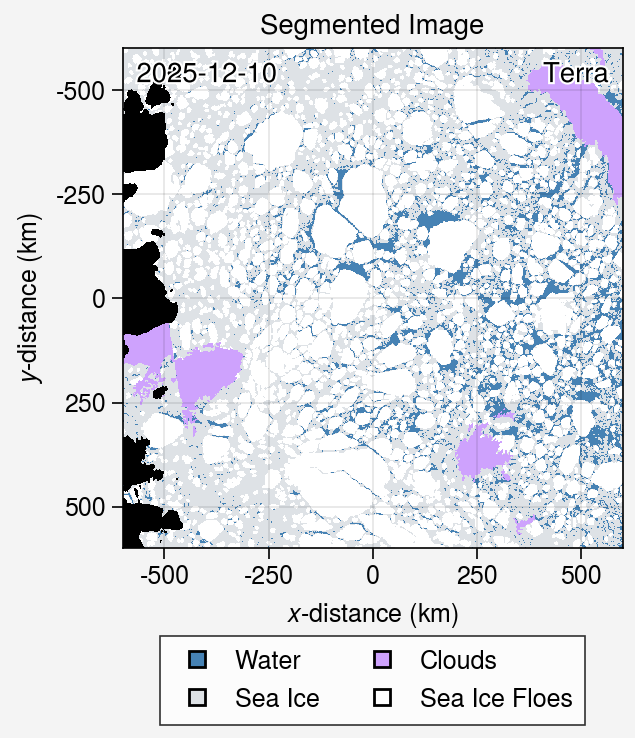

In [73]:
fig, ax = uplt.subplots()
ax.imshow(np.ma.masked_array(ice[plot_date], mask=ice[plot_date]==0), color='gray3')
ax.imshow(np.ma.masked_array(ice[plot_date], mask=ice[plot_date]>0), color='steelblue')
ax.imshow(np.ma.masked_array(segments[plot_date], mask=segments[plot_date]==0), color='w')
ax.imshow(np.ma.masked_array(clouds[plot_date], mask=clouds[plot_date]==0), color='lilac')
ax.imshow(np.ma.masked_array(land, mask=land==0), color='k')

h = [ax.plot([], [], marker='s', edgecolor='k', lw=0, color=color) for color in ['steelblue', 'lilac', 'gray3', 'w']]
ax.legend(h, ['Water',  'Clouds', 'Sea Ice', 'Sea Ice Floes'], ncols=2, loc='b')
ylocs = np.arange(100, 1200, 250)
ax.format(ultitle=plot_date.strftime('%Y-%m-%d'), urtitle=satellites[plot_date].title(), title='Segmented Image',
         ylocator=ylocs, ytickminor=False, ylabel='$y$-distance (km)',
         yformatter=[str(int(x)) for x in (ylocs - 600)],
         xlocator=ylocs, xtickminor=False, xlabel='$x$-distance (km)',
         xformatter=[str(int(x)) for x in (ylocs - 600)])

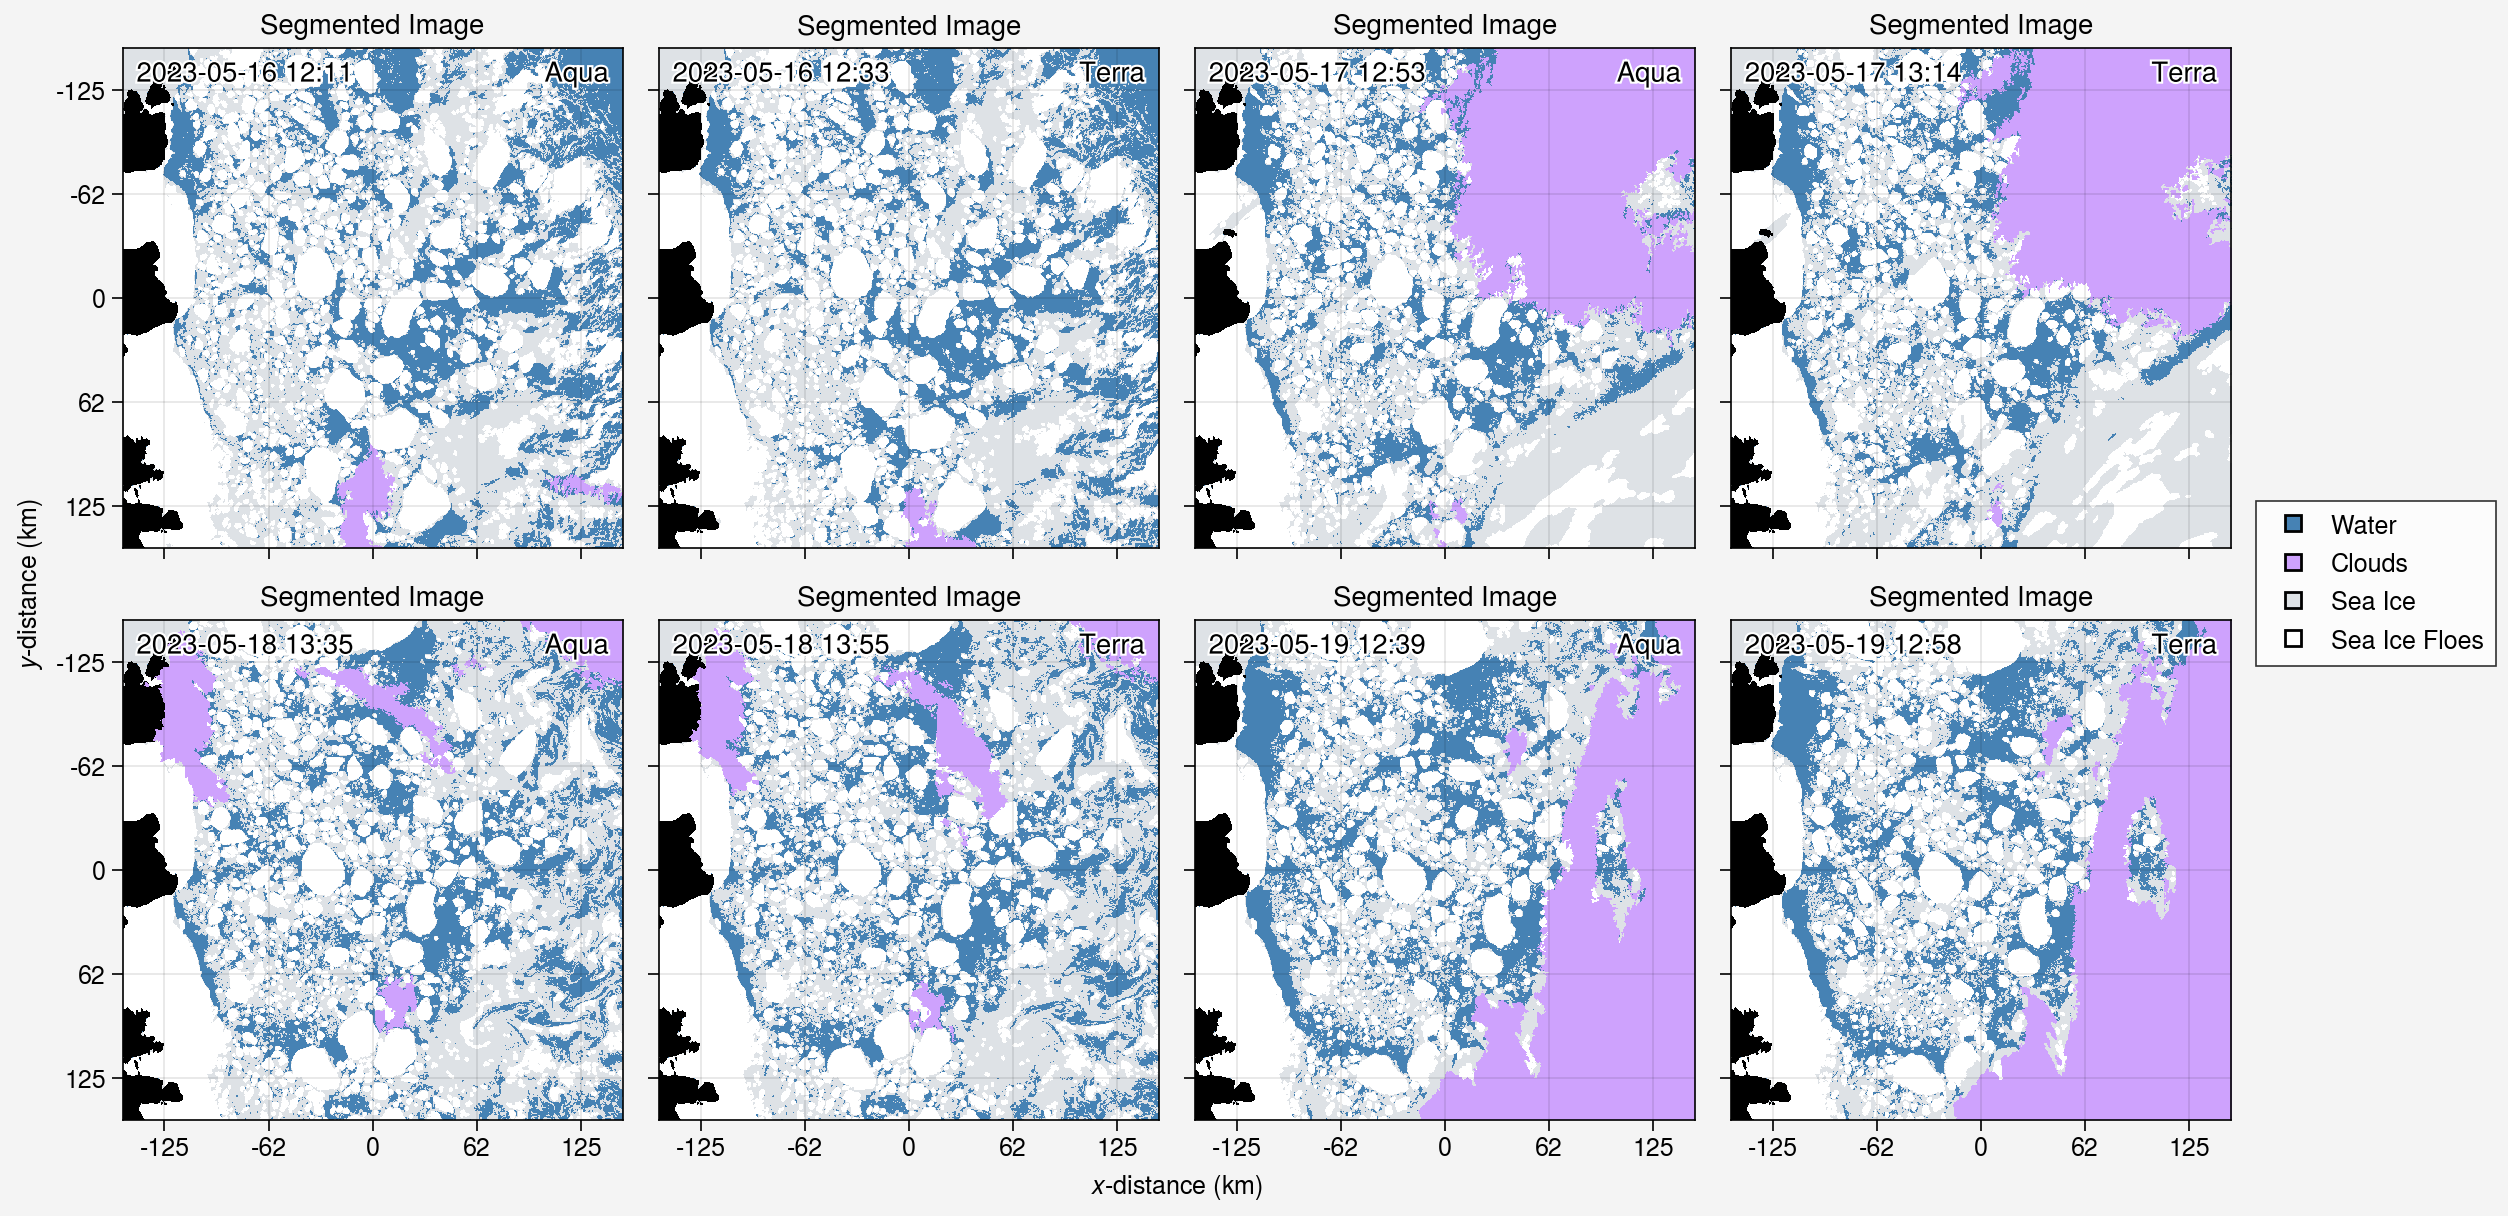

In [76]:
fig, ax = uplt.subplots(ncols=4, nrows=2)
for ax, plot_date in zip(ax, dates):
    ax.imshow(np.ma.masked_array(ice[plot_date], mask=ice[plot_date]==0), color='gray3')
    ax.imshow(np.ma.masked_array(ice[plot_date], mask=ice[plot_date]>0), color='steelblue')
    ax.imshow(np.ma.masked_array(land, mask=land==0), color='k')
    ax.imshow(np.ma.masked_array(segments[plot_date], mask=segments[plot_date]==0), color='w')
    ax.imshow(np.ma.masked_array(clouds[plot_date], mask=clouds[plot_date]==0), color='lilac')
    
    ylocs = np.arange(100, 1200, 250)
    ax.format(ultitle=plot_date.strftime('%Y-%m-%d %H:%M'), urtitle=satellites[plot_date].title(), title='Segmented Image',
             ylocator=ylocs, ytickminor=False, ylabel='$y$-distance (km)',
             yformatter=[str(int(x * 0.25)) for x in (ylocs - 600)],
             xlocator=ylocs, xtickminor=False, xlabel='$x$-distance (km)',
             xformatter=[str(int(x * 0.25)) for x in (ylocs - 600)])

h = [ax.plot([], [], marker='s', edgecolor='k', lw=0, color=color) for color in ['steelblue', 'lilac', 'gray3', 'w']]
fig.legend(h, ['Water',  'Clouds', 'Sea Ice', 'Sea Ice Floes'], ncols=1, loc='r')

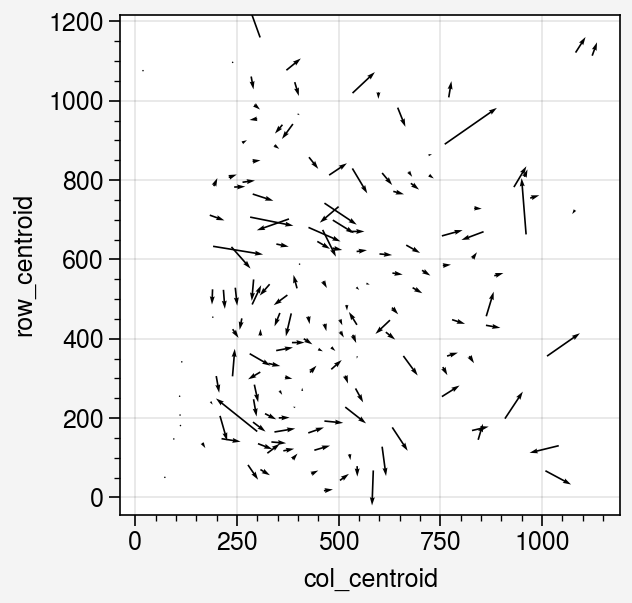

In [81]:
fig, ax = uplt.subplots()
ax.quiver(df_1day.col_centroid, df_1day.row_centroid, du, dv)

In [15]:
df_1day

,ID,trajectory_uuid,head_uuid,uuid,area,col_centroid,convex_area,label,major_axis_length,max_col,...,w,satellite,dt_seconds,dx_meters,dxdt_mps,dt,dx,dy,color,U
1,1,04ribhS2GOE8,NCBPGt1LlgAF,hmFfosGoC0eQ,923,425.963164,942.0,472,39.751969,442,...,0.211164,terra,1320.0,169.924869,0.128731,NaN,NaN,NaN,#522b51ff,NaN
20,5,0TGHztMfdds6,gvvqpxussW1D,3O8RX7lQel21,856,603.781542,869.0,706,35.882232,621,...,0.727915,terra,1320.0,809.273883,0.613086,NaN,NaN,NaN,#be7148ff,NaN
33,7,0hymOpcGMFBq,VY20ygCmpm0L,Zk1vSw8FvOmF,1001,415.393606,1023.0,457,39.942081,433,...,0.286318,terra,1320.0,274.367183,0.207854,NaN,NaN,NaN,#df9d56ff,NaN
40,8,0nQeeFuYcxS4,mr1WaxFm3B69,EDJNQIVKHbBU,688,331.002907,698.0,282,32.701230,347,...,0.236470,terra,1320.0,168.513726,0.127662,NaN,NaN,NaN,#ce864fff,NaN
64,14,1Yyy2wKY4Qn4,GwmC55ZsLheq,K1cVT7ayXRme,585,114.967521,626.0,13,29.100679,130,...,0.239859,terra,1320.0,133.948923,0.101476,NaN,NaN,NaN,#be7148ff,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,589,yRCwW1qX0BVX,Vtutmubdg05C,FWK1TSYm2djm,490,309.738776,520.0,233,29.009774,324,...,0.981729,terra,1320.0,570.442664,0.432154,NaN,NaN,NaN,#5d86c1ff,NaN
2396,590,ybPYu3mv6K3A,cUGQvSF2d94m,AJOlabtsF5O3,316,545.712025,320.0,641,21.846564,555,...,0.230585,terra,1320.0,190.045409,0.143974,NaN,NaN,NaN,#df9d56ff,NaN
2419,595,yo35uZuXe5UJ,7bAbZDQntnej,O7FTvUwuDlFM,335,822.605970,340.0,931,24.846270,835,...,0.519951,terra,1320.0,314.990313,0.238629,NaN,NaN,NaN,#5671afff,NaN
2427,597,yvp69uI6n2WL,iVsvLUajuABc,zpkyLXG2riVB,822,328.463504,877.0,260,37.146145,345,...,0.344633,terra,1320.0,302.970015,0.229523,NaN,NaN,NaN,#843b39ff,NaN


/opt/homebrew/Caskroom/miniconda/base/envs/ift_jog/lib/python3.13/site-packages/matplotlib/quiver.py:678: RuntimeWarning: Mean of empty slice.
  amean = a.mean()
/opt/homebrew/Caskroom/miniconda/base/envs/ift_jog/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


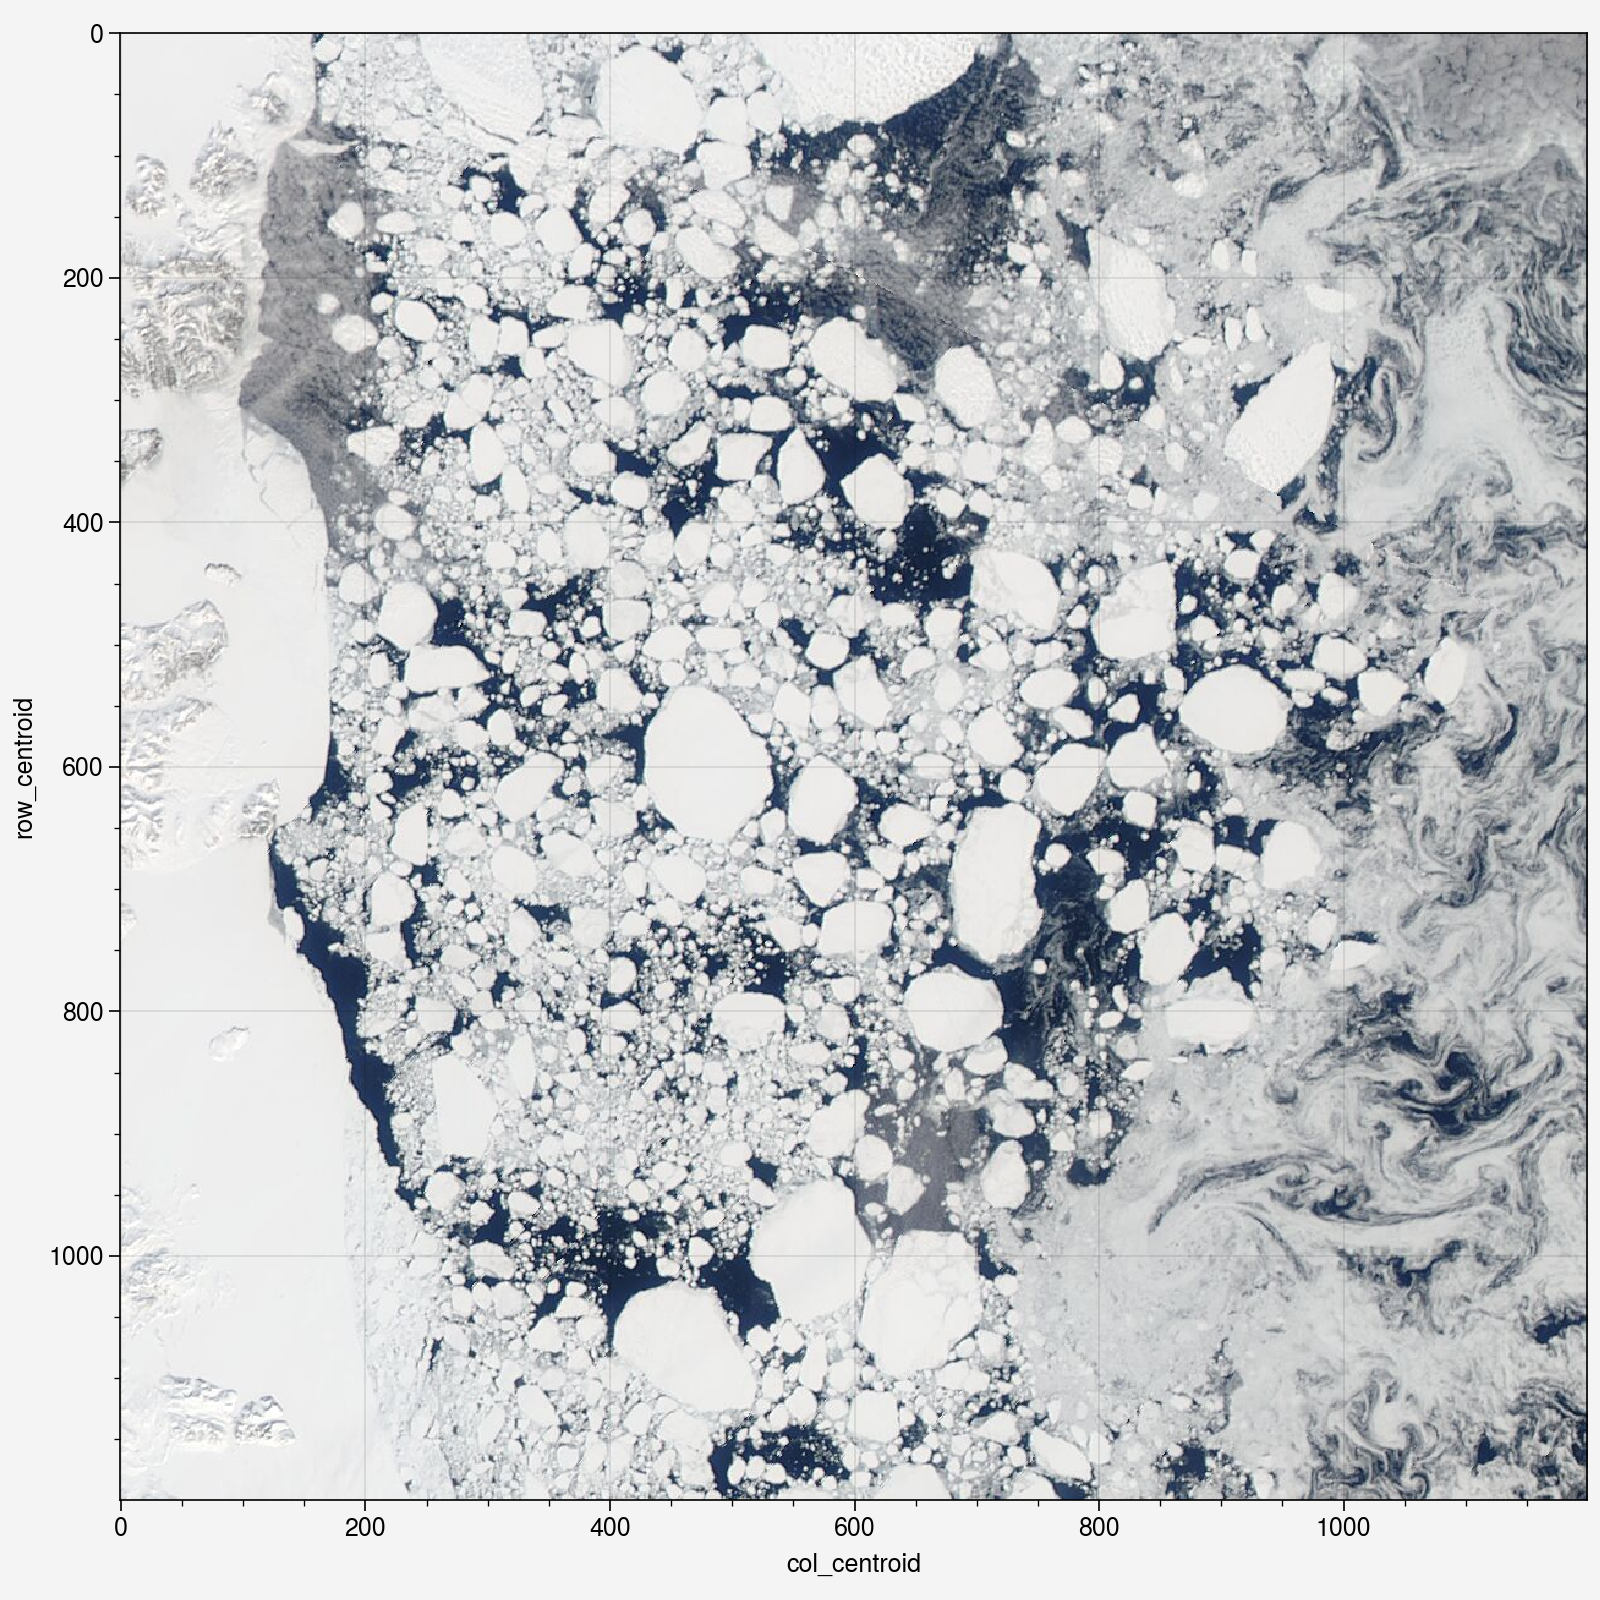

In [14]:
plot_date = dates[4]
fig, ax = uplt.subplots(height=8, width=8)
ax.imshow(images[plot_date])
# ax.scatter(df_1day.col_centroid, df_1day.row_centroid, marker='o', c=df_1day.U, vmin=0, vmax=0.2, cmap='spectral', colorbar='r')    
# for ID, group in df_1day.groupby("ID"):
#     if group.U.max() < 0.15:
#         ax.plot(group.col_centroid, group.row_centroid, marker='.', ms=3)

du = df_1day.dx / df_1day.dt
dv = df_1day.dy / df_1day.dt
zu = (du - du.mean())/du.std()
zv = (dv - dv.mean())/dv.std()

idx = (zu**2 + zv**2)**0.5 < 25


# plot_date = pd.Timestamp('2025-12-10 08:59:00')
# antarctic_tc = images[plot_date]
# antarctic_clouds = clouds[plot_date]
# antarctic_ice = ice[plot_date]
# antarctic_segments = segments[plot_date]
# antarctic_date = plot_date.strftime('%Y-%m-%d')

# antarctic_x = df_1day.col_centroid[idx]
# antarctic_y = df_1day.row_centroid[idx]
# antarctic_u = (df_1day.dx/df_1day.dt)[idx]
# antarctic_v = (df_1day.dy/df_1day.dt)[idx]

ax.quiver(df_1day.col_centroid[idx],
          df_1day.row_centroid[idx],
          (df_1day.dx/df_1day.dt)[idx],
          (df_1day.dy/df_1day.dt)[idx],
          zorder=2, width=1/500)    
ax.format(xreverse=False, yreverse=True)

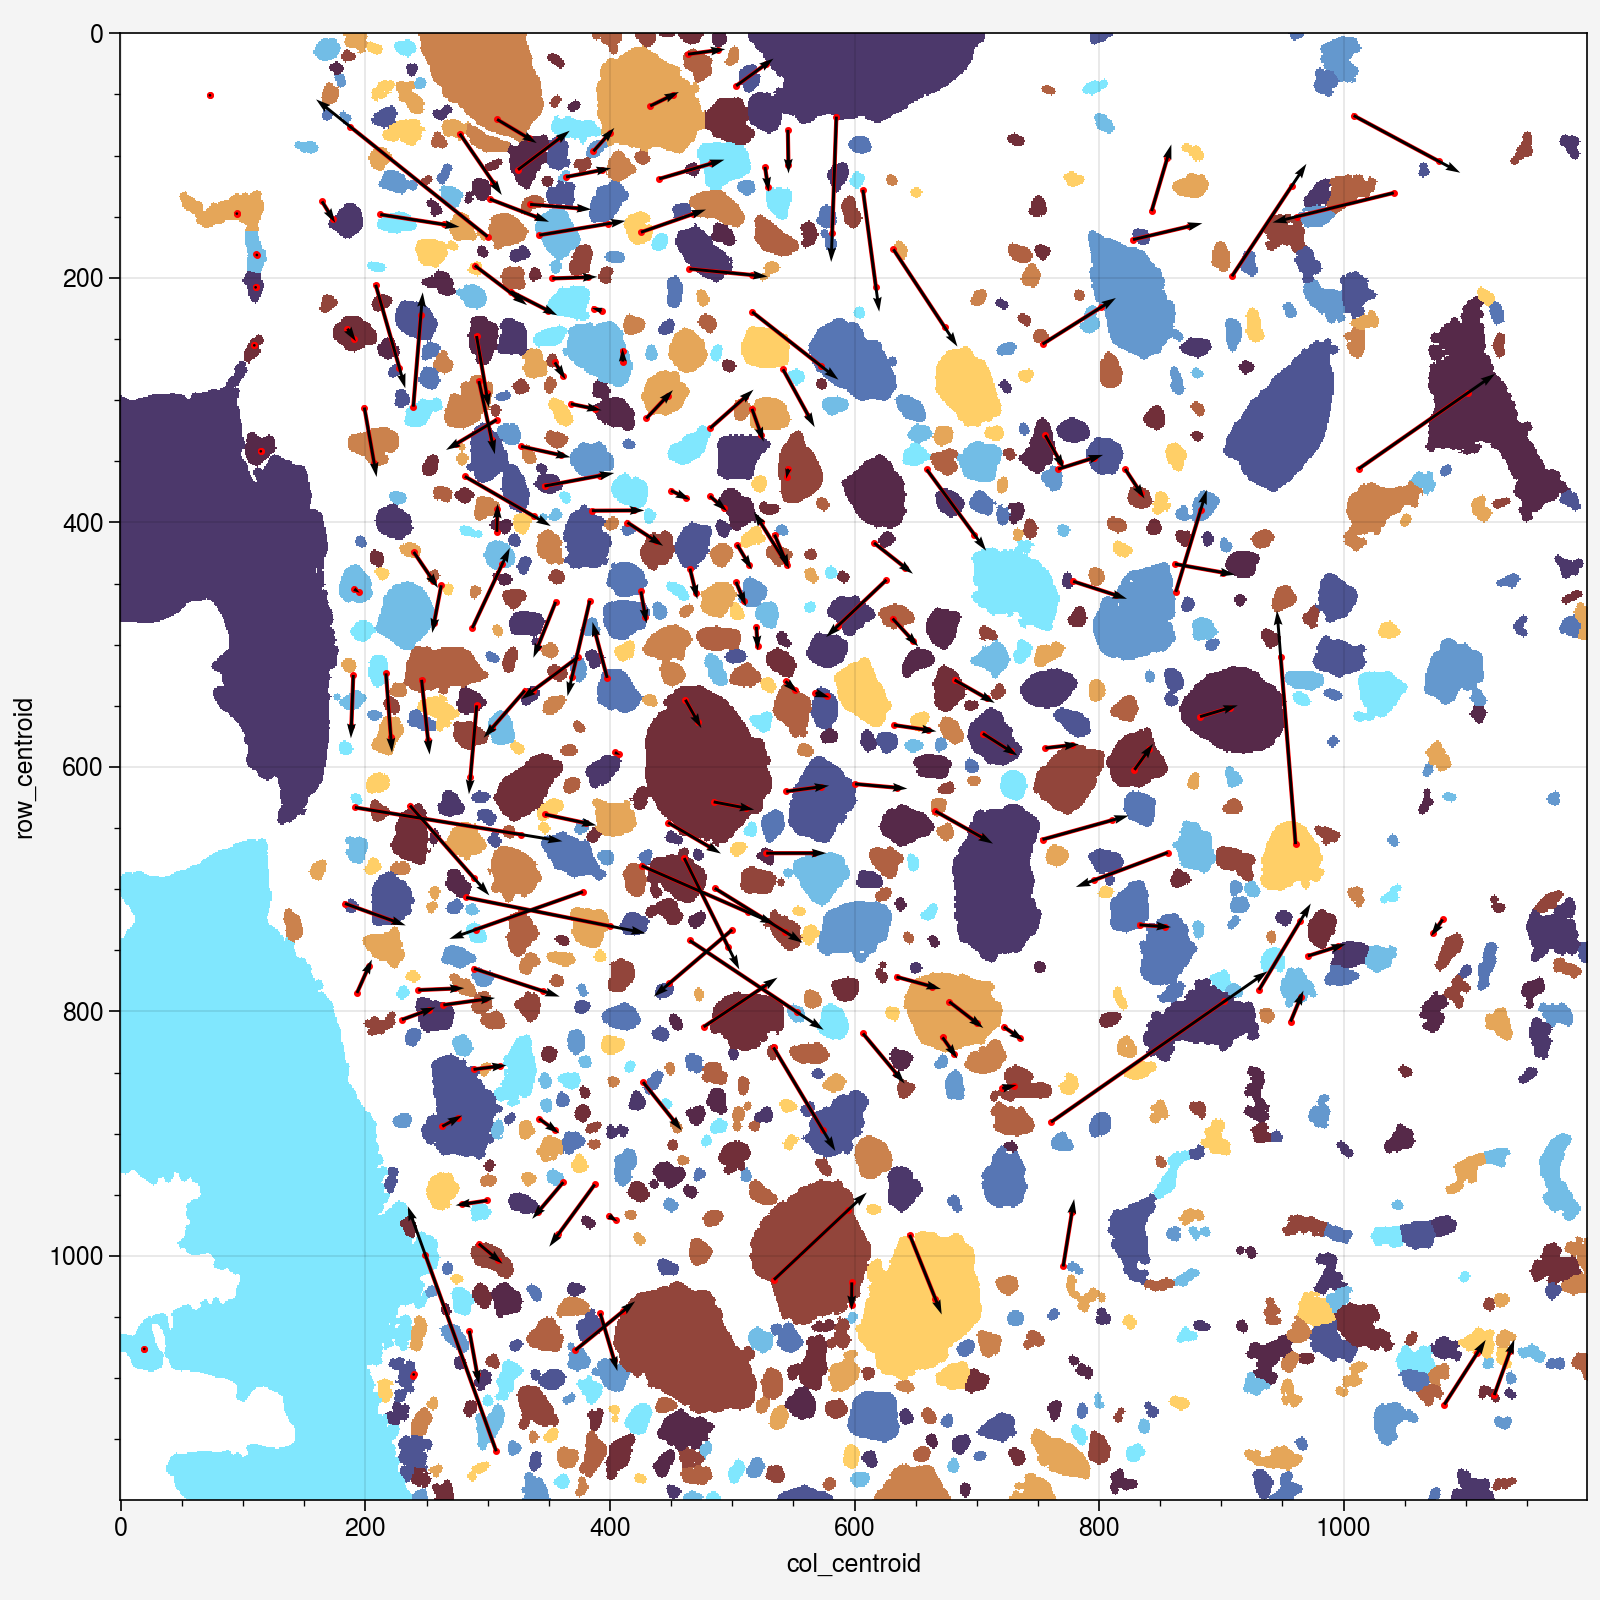

In [77]:
fig, ax = uplt.subplots(height=8, width=8)
ax.imshow(np.ma.masked_array(segments[dates[4]] % 13, mask=segments[dates[4]]==0), cmap='managua', alpha=1)
outlines = (segments[dates[6]] > 0).astype(int) - skimage.morphology.erosion(segments[dates[6]] > 0).astype(int)
# ax.imshow(np.ma.masked_array(outlines, mask=outlines==0), color='k', alpha=1)

# ax.scatter(df_1day.col_centroid, df_1day.row_centroid, marker='o')    
for ID, group in df_1day.groupby("ID"):
    if group.U.max() < 0.5:
        ax.plot(group.col_centroid, group.row_centroid, marker='.', ms=3, color='r')

du = df_1day.dx / df_1day.dt
dv = df_1day.dy / df_1day.dt
zu = (du - du.mean())/du.std()
zv = (dv - dv.mean())/dv.std()

idx = (zu**2 + zv**2)**0.5 < 25

ax.quiver(df_1day.col_centroid[idx],
          df_1day.row_centroid[idx],
          (df_1day.dx/df_1day.dt)[idx],
          (df_1day.dy/df_1day.dt)[idx],
          zorder=2, width=1/500)    

ax.format(xreverse=False, yreverse=True)

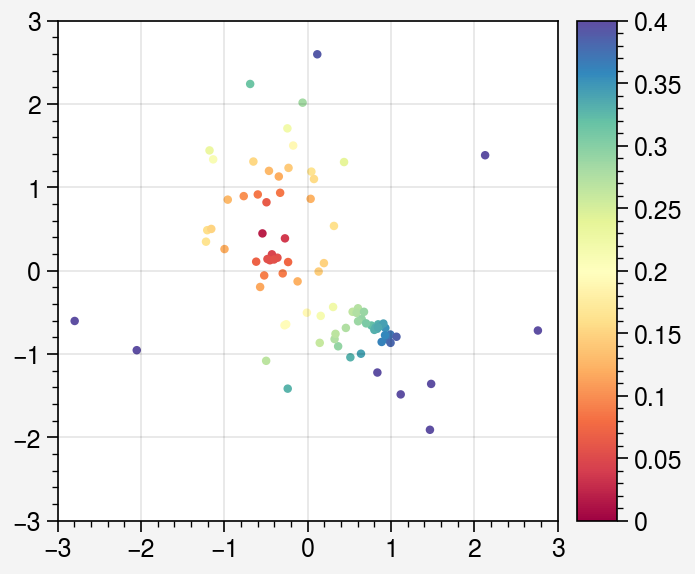

In [323]:
fig, ax = uplt.subplots()
du = df_1day.dx / df_1day.dt
dv = df_1day.dy / df_1day.dt
zu = (du - du.mean())/du.std()
zv = (dv - dv.mean())/dv.std()

ax.scatter((du - du.mean())/du.std(), (dv - dv.mean())/dv.std(), ms=6, c=df_1day.U, cmap='spectral', colorbar='r', vmin=0, vmax=0.4)
ax.format(ylim=(-3, 3), xlim=(-3, 3))

In [253]:
du.std()

np.float64(0.12075410157514412)

In [218]:
u = df_1day.dx / df_1day.dt
u[u > 0].quantile(0.5)

np.float64(0.02028986068681179)

(array([24., 53., 50., 33.,  5.,  3.,  6.,  3.,  1.,  5.,  3.,  0.,  1.,
         0.,  2.,  1.,  1.,  2.,  1.]),
 array([0.        , 0.01578947, 0.03157895, 0.04736842, 0.06315789,
        0.07894737, 0.09473684, 0.11052632, 0.12631579, 0.14210526,
        0.15789474, 0.17368421, 0.18947368, 0.20526316, 0.22105263,
        0.23684211, 0.25263158, 0.26842105, 0.28421053, 0.3       ]),
 <BarContainer object of 19 artists>)

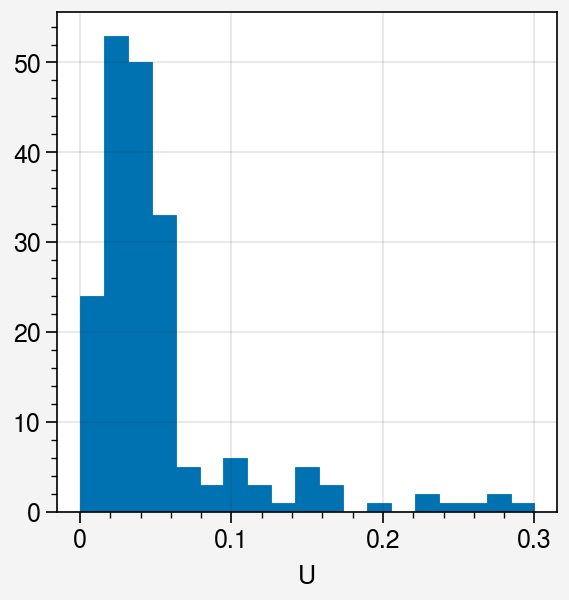

In [227]:
fig, ax = uplt.subplots()
ax.hist(df_1day.U, bins=np.linspace(0, 0.3, 20))